# Install lib


In [50]:
!pip install pandas matplotlib numpy seaborn 


[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: C:\Users\fabot\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


# import lib / data

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
df = pd.read_csv("../data/processed/enriched_data.csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 32 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   transaction_id              120000 non-null  object 
 1   transaction_date            120000 non-null  object 
 2   customer_id                 120000 non-null  object 
 3   customer_gender             120000 non-null  object 
 4   customer_age_group          120000 non-null  object 
 5   customer_segment            120000 non-null  object 
 6   product_id                  120000 non-null  object 
 7   product_name                120000 non-null  object 
 8   category                    120000 non-null  object 
 9   brand                       120000 non-null  object 
 10  quantity                    120000 non-null  float64
 11  unit_price                  120000 non-null  float64
 12  discount_pct                120000 non-null  int64  
 13  sales_amount  

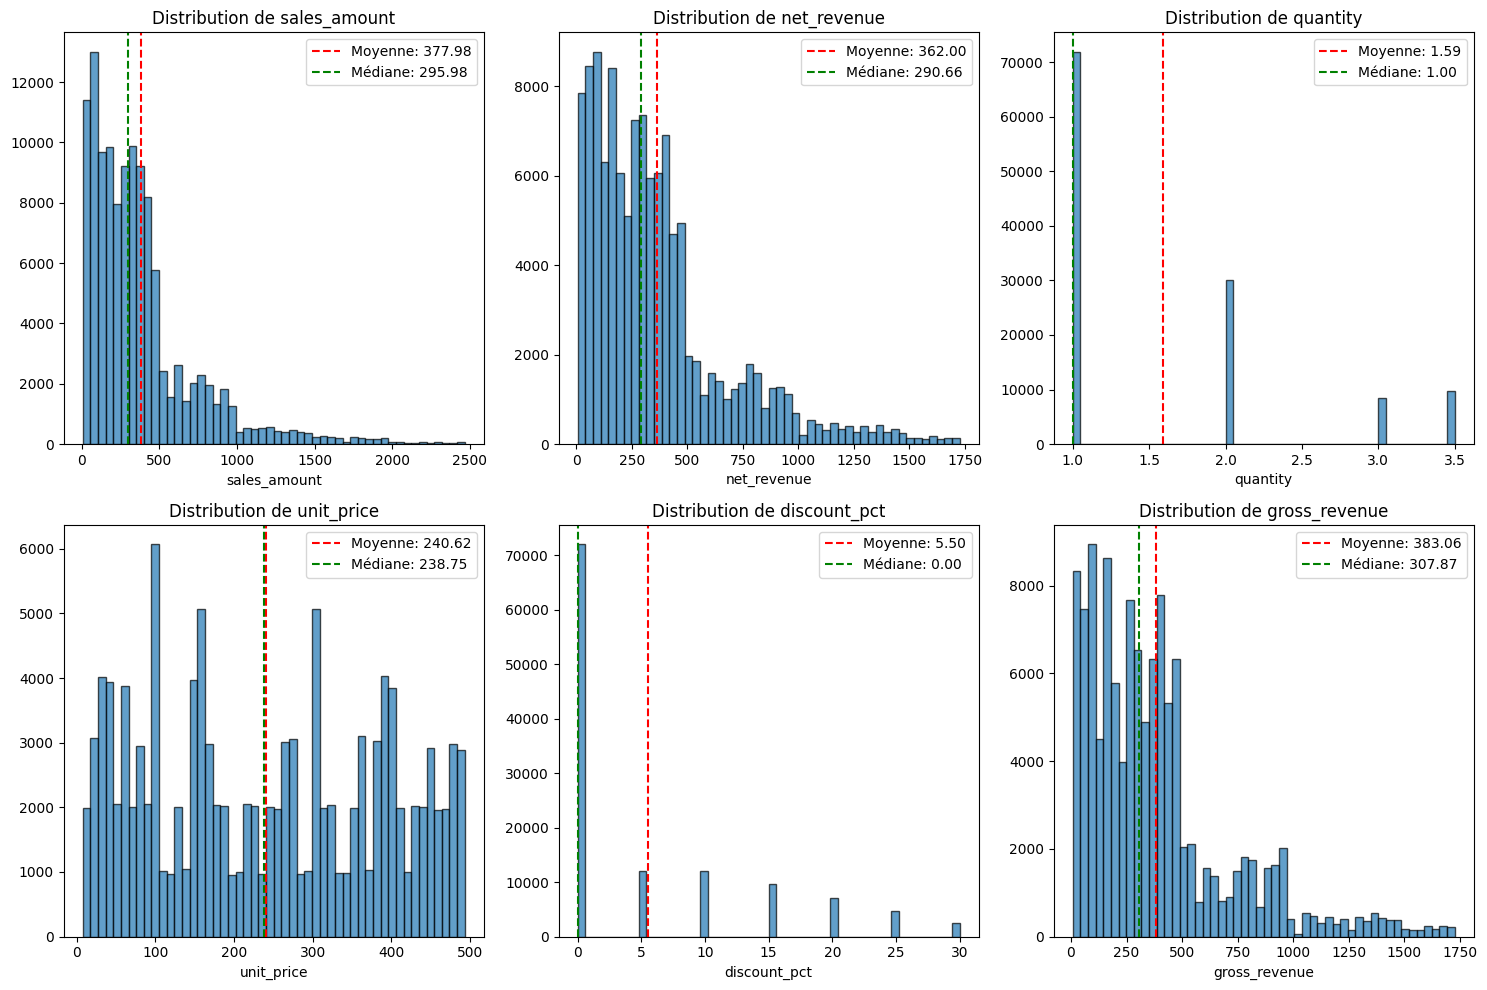

In [53]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
numerical_cols = ['sales_amount', 'net_revenue', 'quantity', 'unit_price', 'discount_pct', 'gross_revenue']
for idx, col in enumerate(numerical_cols):
    row = idx // 3
    col_idx = idx % 3
    
    axes[row, col_idx].hist(df[col], bins=50, edgecolor='black', alpha=0.7)
    
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[row, col_idx].axvline(mean_val, color='red', linestyle='--', label=f'Moyenne: {mean_val:.2f}')
    axes[row, col_idx].axvline(median_val, color='green', linestyle='--', label=f'Médiane: {median_val:.2f}')
    
    axes[row, col_idx].set_title(f'Distribution de {col}')
    axes[row, col_idx].legend()
    axes[row, col_idx].set_xlabel(col)

plt.tight_layout()
plt.show()

Colonnes catégorielles : ['transaction_id', 'transaction_date', 'customer_id', 'customer_gender', 'customer_age_group', 'customer_segment', 'product_id', 'product_name', 'category', 'brand', 'payment_method', 'sales_channel', 'region', 'day_of_week']


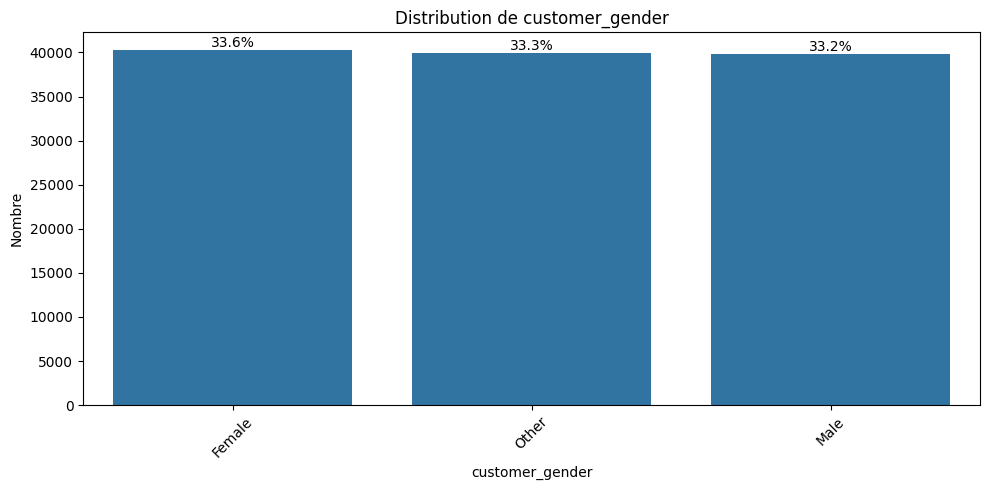

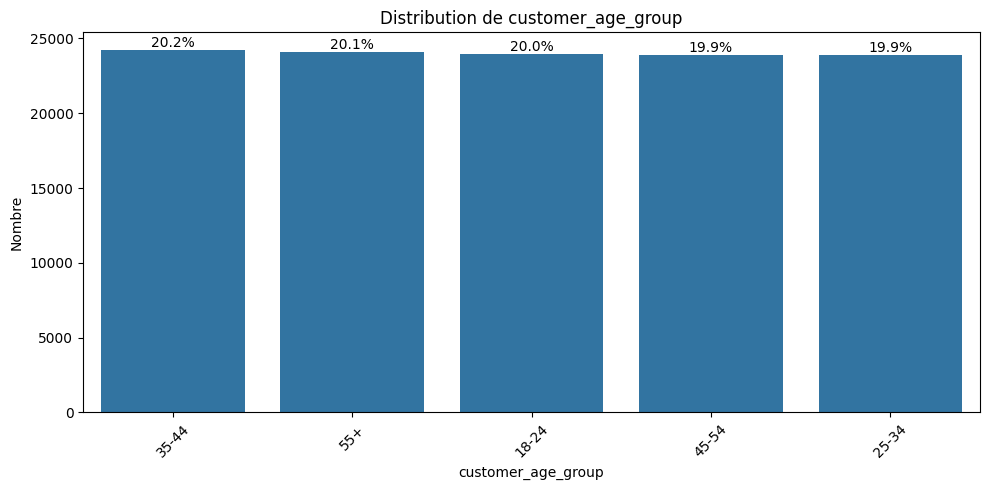

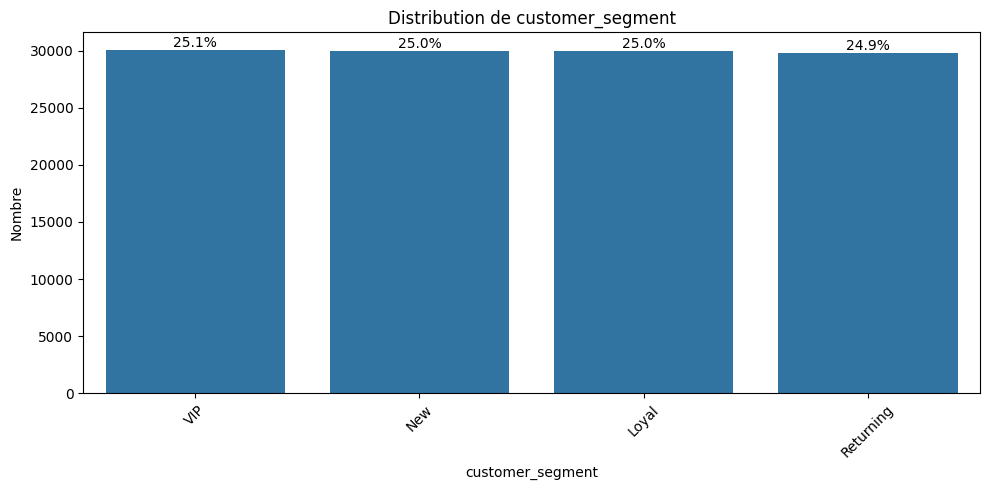

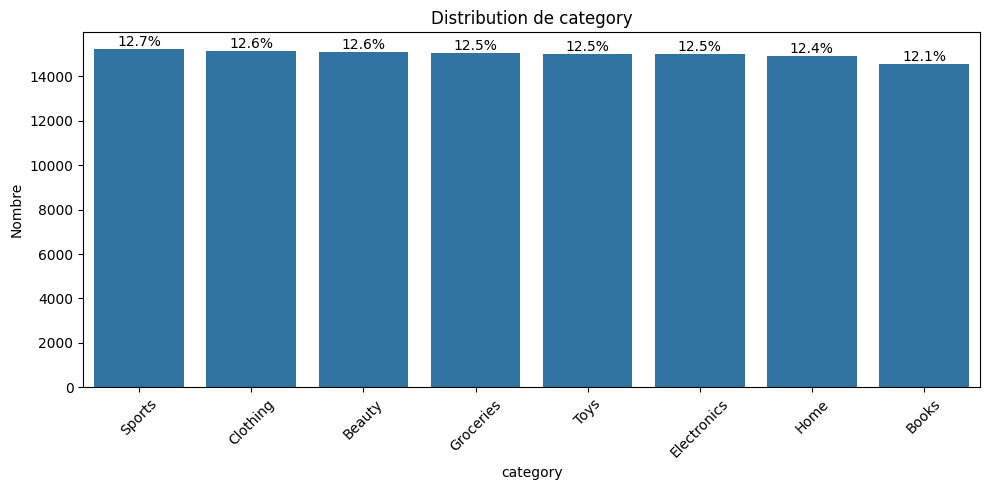

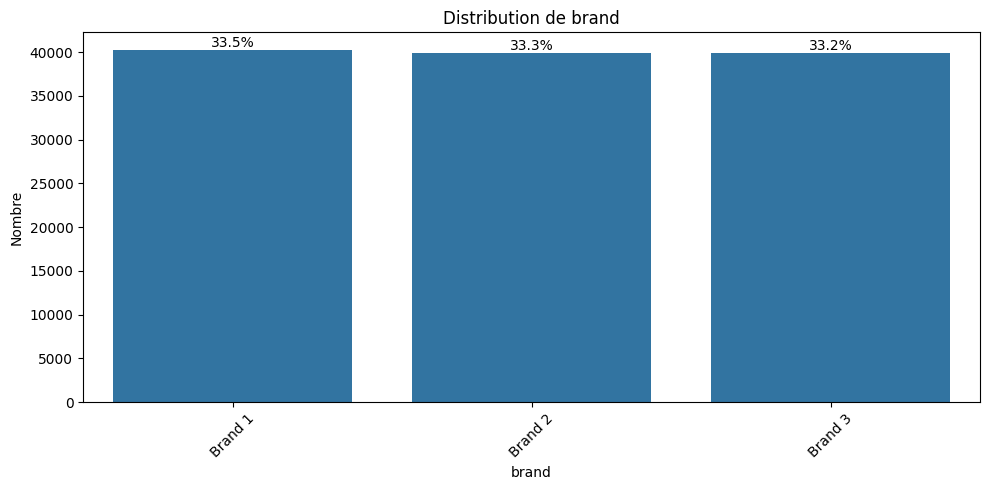

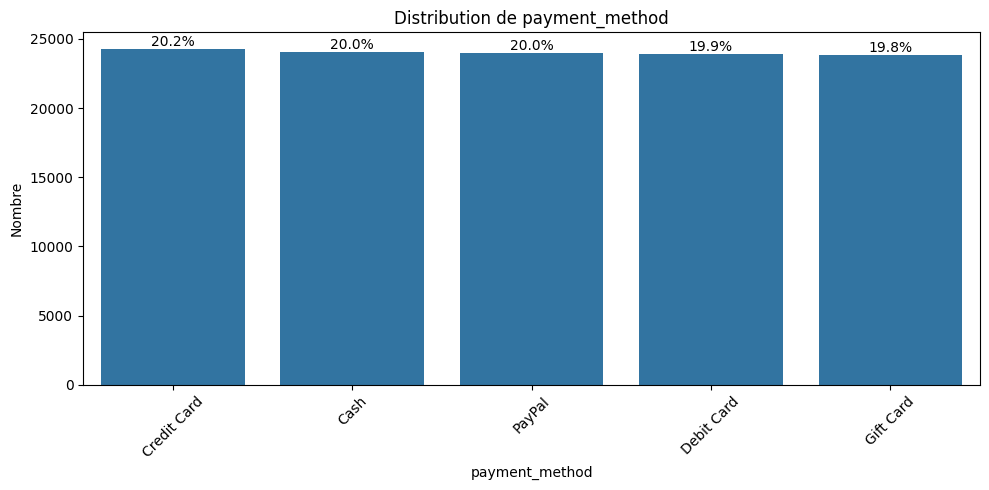

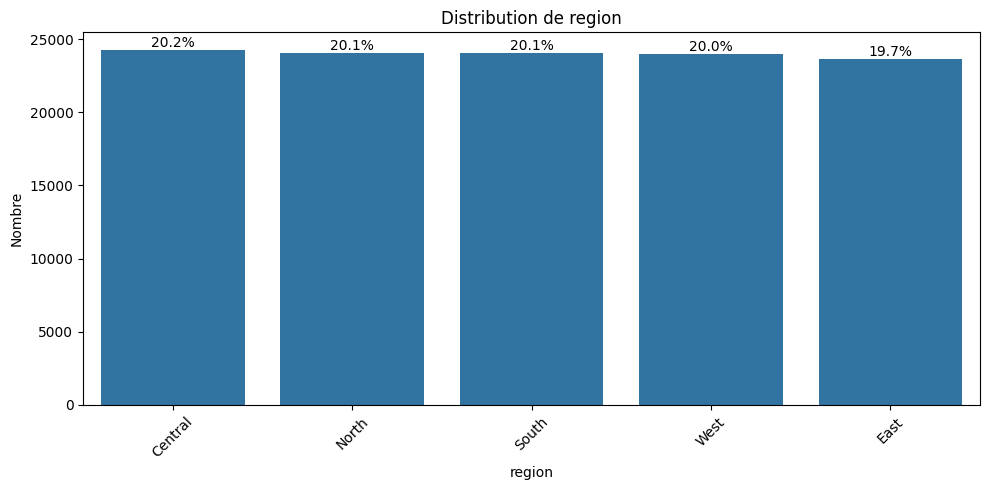

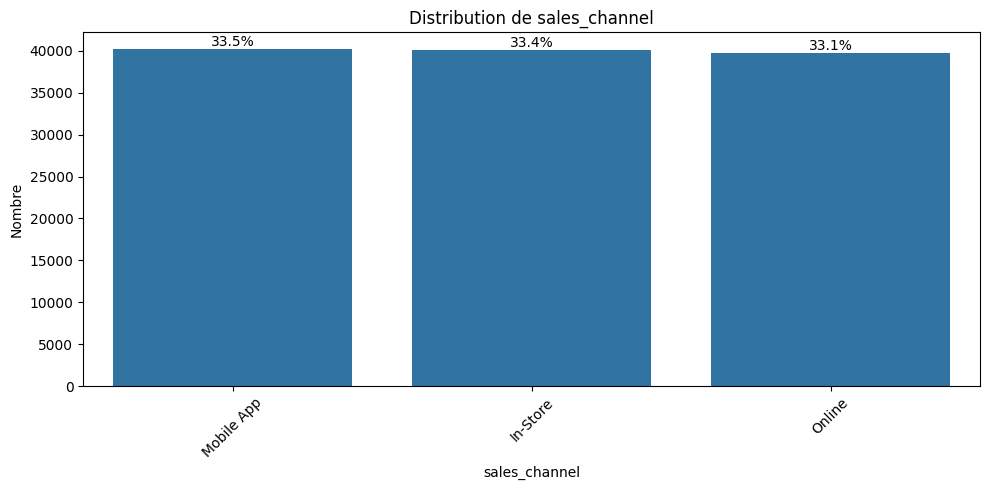

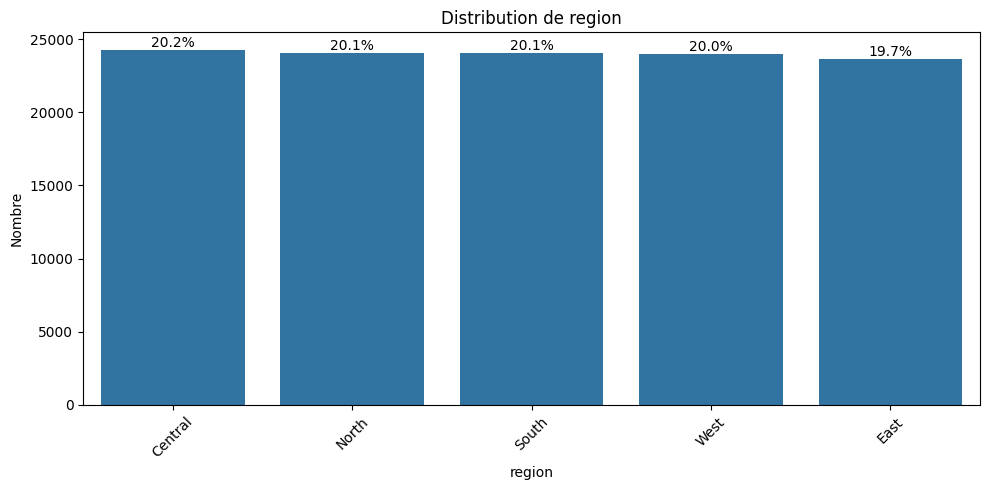

In [54]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Colonnes catégorielles : {categorical_cols}")

categorical_cols = ["customer_gender","customer_age_group","customer_segment","category", "brand", "payment_method", "region","sales_channel","region"]

for col in categorical_cols:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    sns.countplot(data=df, x=col, ax=ax, 
                 order=df[col].value_counts().index)
    
    total = len(df)
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        ax.annotate(percentage, 
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='bottom')
    
    ax.set_title(f'Distribution de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Nombre')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

                     CA_total  CA_moyen  nb_transactions  nb_clients  \
customer_segment                                                       
Loyal             10906615.93    363.38            30014       17336   
New               10851631.53    361.48            30020       17524   
Returning         10830787.52    362.83            29851       17435   
VIP               10851062.42    360.32            30115       17535   

                  CA_par_client  
customer_segment                 
Loyal                    629.13  
New                      619.24  
Returning                621.21  
VIP                      618.82  


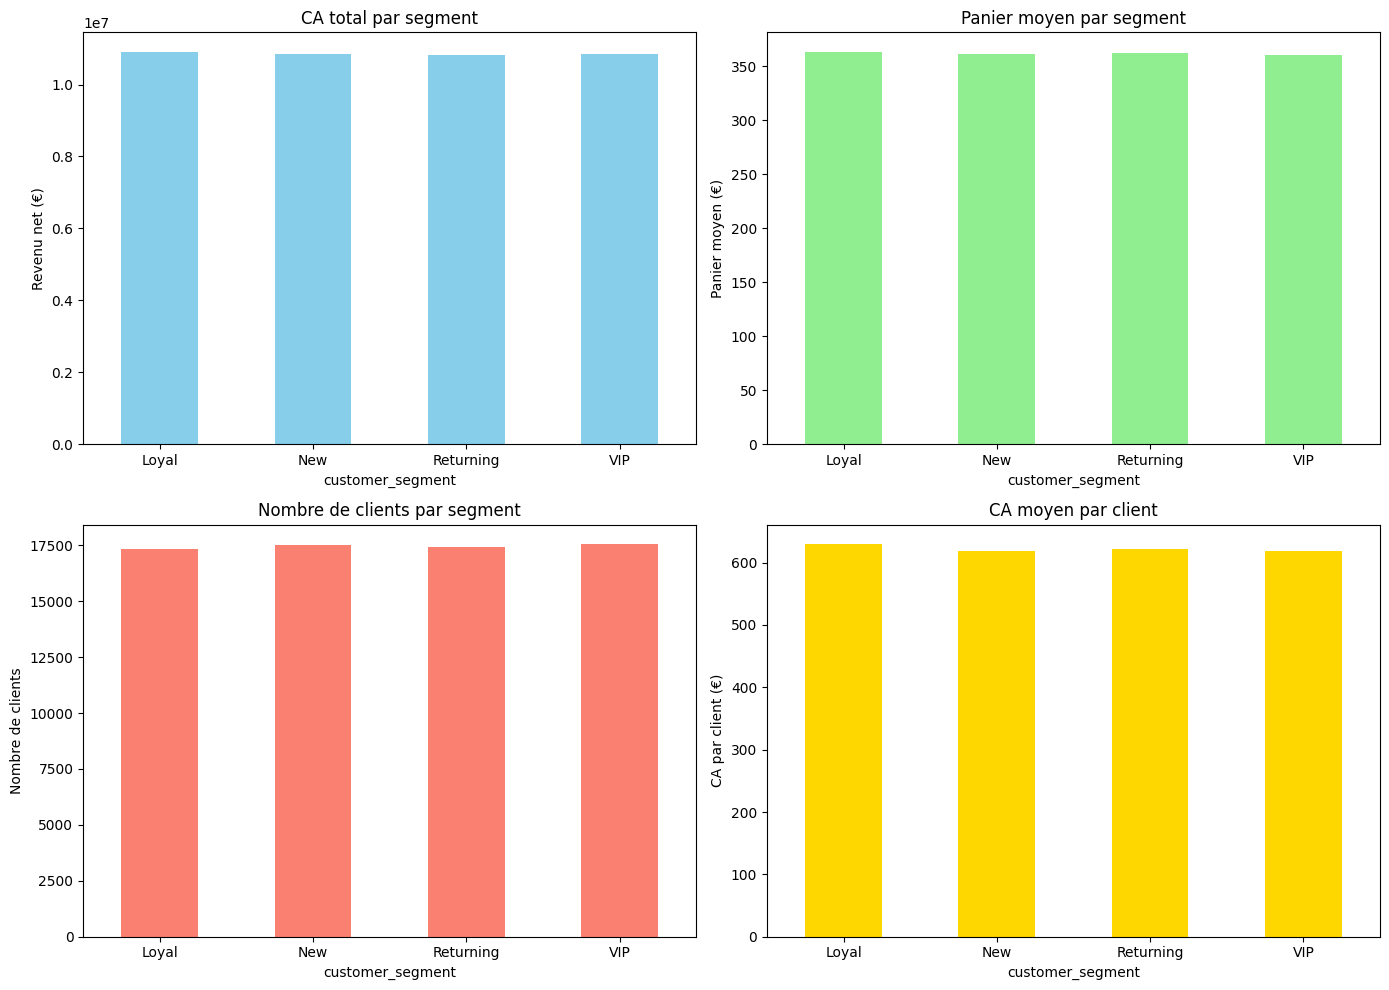

In [55]:
segment_stats = df.groupby('customer_segment').agg({
    'net_revenue': ['sum', 'mean', 'count'],
    'customer_id': 'nunique'
}).round(2)

segment_stats.columns = ['CA_total', 'CA_moyen', 'nb_transactions', 'nb_clients']
segment_stats['CA_par_client'] = (segment_stats['CA_total'] / segment_stats['nb_clients']).round(2)

print(segment_stats)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

segment_stats['CA_total'].plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('CA total par segment')
axes[0, 0].set_ylabel('Revenu net (€)')
axes[0, 0].tick_params(axis='x', rotation=0)


segment_stats['CA_moyen'].plot(kind='bar', ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Panier moyen par segment')
axes[0, 1].set_ylabel('Panier moyen (€)')
axes[0, 1].tick_params(axis='x', rotation=0)

segment_stats['nb_clients'].plot(kind='bar', ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Nombre de clients par segment')
axes[1, 0].set_ylabel('Nombre de clients')
axes[1, 0].tick_params(axis='x', rotation=0)

segment_stats['CA_par_client'].plot(kind='bar', ax=axes[1, 1], color='gold')
axes[1, 1].set_title('CA moyen par client')
axes[1, 1].set_ylabel('CA par client (€)')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

          CA_total  CA_moyen  nb_transactions   mois_nom
months                                                  
1       3747548.36    366.83            10216    Janvier
2       3441340.34    364.78             9434    Février
3       3552404.71    351.62            10103       Mars
4       3571319.54    361.91             9868      Avril
5       3714344.74    362.38            10250        Mai
6       3571955.02    359.39             9939       Juin
7       3735347.50    365.42            10222    Juillet
8       3735869.12    367.13            10176       Août
9       3538538.22    359.53             9842  Septembre
10      3612451.59    360.42            10023    Octobre
11      3587622.22    363.63             9866   Novembre
12      3631356.04    360.93            10061   Décembre


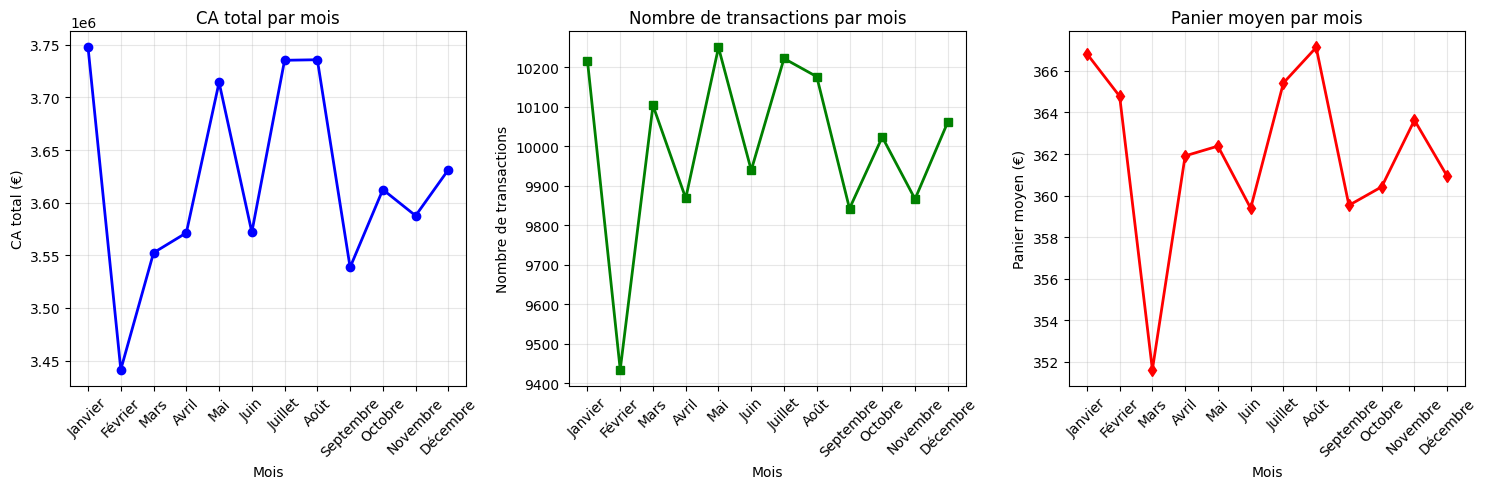

In [56]:
monthly_sales = df.groupby('months').agg({
    'net_revenue': ['sum', 'mean', 'count']
}).round(2)
monthly_sales.columns = ['CA_total', 'CA_moyen', 'nb_transactions']

month_mapping = {
    1: 'Janvier', 2: 'Février', 3: 'Mars', 4: 'Avril',
    5: 'Mai', 6: 'Juin', 7: 'Juillet', 8: 'Août',
    9: 'Septembre', 10: 'Octobre', 11: 'Novembre', 12: 'Décembre'
}

monthly_sales['mois_nom'] = monthly_sales.index.map(month_mapping)

print(monthly_sales)

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(monthly_sales.index, monthly_sales['CA_total'], 
             marker='o', color='blue', linewidth=2)

axes[0].set_xticks(monthly_sales.index)
axes[0].set_xticklabels(monthly_sales['mois_nom'], rotation=45)
axes[0].set_title('CA total par mois')
axes[0].set_xlabel('Mois')
axes[0].set_ylabel('CA total (€)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(monthly_sales.index, monthly_sales['nb_transactions'], 
             marker='s', color='green', linewidth=2)
axes[1].set_xticks(monthly_sales.index)
axes[1].set_xticklabels(monthly_sales['mois_nom'], rotation=45)
axes[1].set_title('Nombre de transactions par mois')
axes[1].set_xlabel('Mois')
axes[1].set_ylabel('Nombre de transactions')
axes[1].grid(True, alpha=0.3)

axes[2].plot(monthly_sales.index, monthly_sales['CA_moyen'], 
             marker='d', color='red', linewidth=2)
axes[2].set_xticks(monthly_sales.index)
axes[2].set_xticklabels(monthly_sales['mois_nom'], rotation=45)
axes[2].set_title('Panier moyen par mois')
axes[2].set_xlabel('Mois')
axes[2].set_ylabel('Panier moyen (€)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [57]:
print("client insights")
segment_revenue = df.groupby('customer_segment')['net_revenue'].sum().sort_values(ascending=False)
segment_pct = (segment_revenue / df['net_revenue'].sum() * 100).round(1)

for segment, pct in segment_pct.items():
    print(f"   - {segment}: {pct:.1f}% du CA total")

top_segment = segment_revenue.index[0]
print(f"\nSegment le plus rentable : {top_segment} ({segment_pct[0]:.1f}% du CA)")

# 2. PRODUITS
print("PRODUITS :")
top_product = df.groupby('product_name')['net_revenue'].sum().sort_values(ascending=False).head(5)
print("   Top 5 produits :")

for i, (product, revenue) in enumerate(top_product.items(), 1):
    print(f"   {i}. {product} : {revenue:,.0f}€")

# 3. TEMPOREL
print("TEMPOREL :")
monthly_total = df.groupby('months')['net_revenue'].sum()
best_month = monthly_total.idxmax()
worst_month = monthly_total.idxmin()
best_value = monthly_total.max()
worst_value = monthly_total.min()

month_names = {1:'Janvier',2:'Février',3:'Mars',4:'Avril',5:'Mai',6:'Juin',
               7:'Juillet',8:'Août',9:'Septembre',10:'Octobre',11:'Novembre',12:'Décembre'}

print(f"   - Meilleur mois : {month_names[best_month]} ({best_value:,.0f}€)")
print(f"   - Mois le plus faible : {month_names[worst_month]} ({worst_value:,.0f}€)")
print(f"   - Différence : {(best_value - worst_value):,.0f}€")

# 4. GÉOGRAPHIE
print("GÉOGRAPHIE :")
region_revenue = df.groupby('region')['net_revenue'].sum().sort_values(ascending=False)
for region, revenue in region_revenue.items():
    pct = (revenue / df['net_revenue'].sum() * 100).round(1)
    print(f"   - {region}: {pct:.1f}% du CA")

# 5. CANAUX
print("CANAUX DE VENTE :")
channel_revenue = df.groupby('sales_channel')['net_revenue'].sum().sort_values(ascending=False)
for channel, revenue in channel_revenue.items():
    pct = (revenue / df['net_revenue'].sum() * 100).round(1)
    print(f"   - {channel}: {pct:.1f}% du CA")

#RÉDUCTIONS
print("\n🔹 IMPACT DES RÉDUCTIONS :")
avg_with = df[df['discount']==True]['net_revenue'].mean()
avg_without = df[df['discount']==False]['net_revenue'].mean()
count_with = len(df[df['discount']==True])
count_without = len(df[df['discount']==False])

print(f"   - Transactions avec réduction : {count_with:,} ({count_with/len(df)*100:.1f}%)")
print(f"   - Transactions sans réduction : {count_without:,} ({count_without/len(df)*100:.1f}%)")
print(f"   - Panier moyen avec réduction : {avg_with:.2f}€")
print(f"   - Panier moyen sans réduction : {avg_without:.2f}€")
print(f"   - Différence : {(avg_without - avg_with):.2f}€")

client insights
   - Loyal: 25.1% du CA total
   - New: 25.0% du CA total
   - VIP: 25.0% du CA total
   - Returning: 24.9% du CA total

Segment le plus rentable : Loyal (25.1% du CA)
PRODUITS :
   Top 5 produits :
   1. Bread : 1,988,206€
   2. Lipstick : 1,973,647€
   3. Textbook : 1,668,562€
   4. Smartphone : 1,563,223€
   5. Water Bottle : 1,530,713€
TEMPOREL :
   - Meilleur mois : Janvier (3,747,548€)
   - Mois le plus faible : Février (3,441,340€)
   - Différence : 306,208€
GÉOGRAPHIE :
   - Central: 20.4% du CA
   - West: 20.1% du CA
   - North: 20.0% du CA
   - South: 19.9% du CA
   - East: 19.8% du CA
CANAUX DE VENTE :
   - In-Store: 33.7% du CA
   - Mobile App: 33.2% du CA
   - Online: 33.1% du CA

🔹 IMPACT DES RÉDUCTIONS :
   - Transactions avec réduction : 48,044 (40.0%)
   - Transactions sans réduction : 71,956 (60.0%)
   - Panier moyen avec réduction : 331.25€
   - Panier moyen sans réduction : 382.53€
   - Différence : 51.27€


C:\Users\fabot\AppData\Local\Temp\ipykernel_17040\2644470662.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"\nSegment le plus rentable : {top_segment} ({segment_pct[0]:.1f}% du CA)")


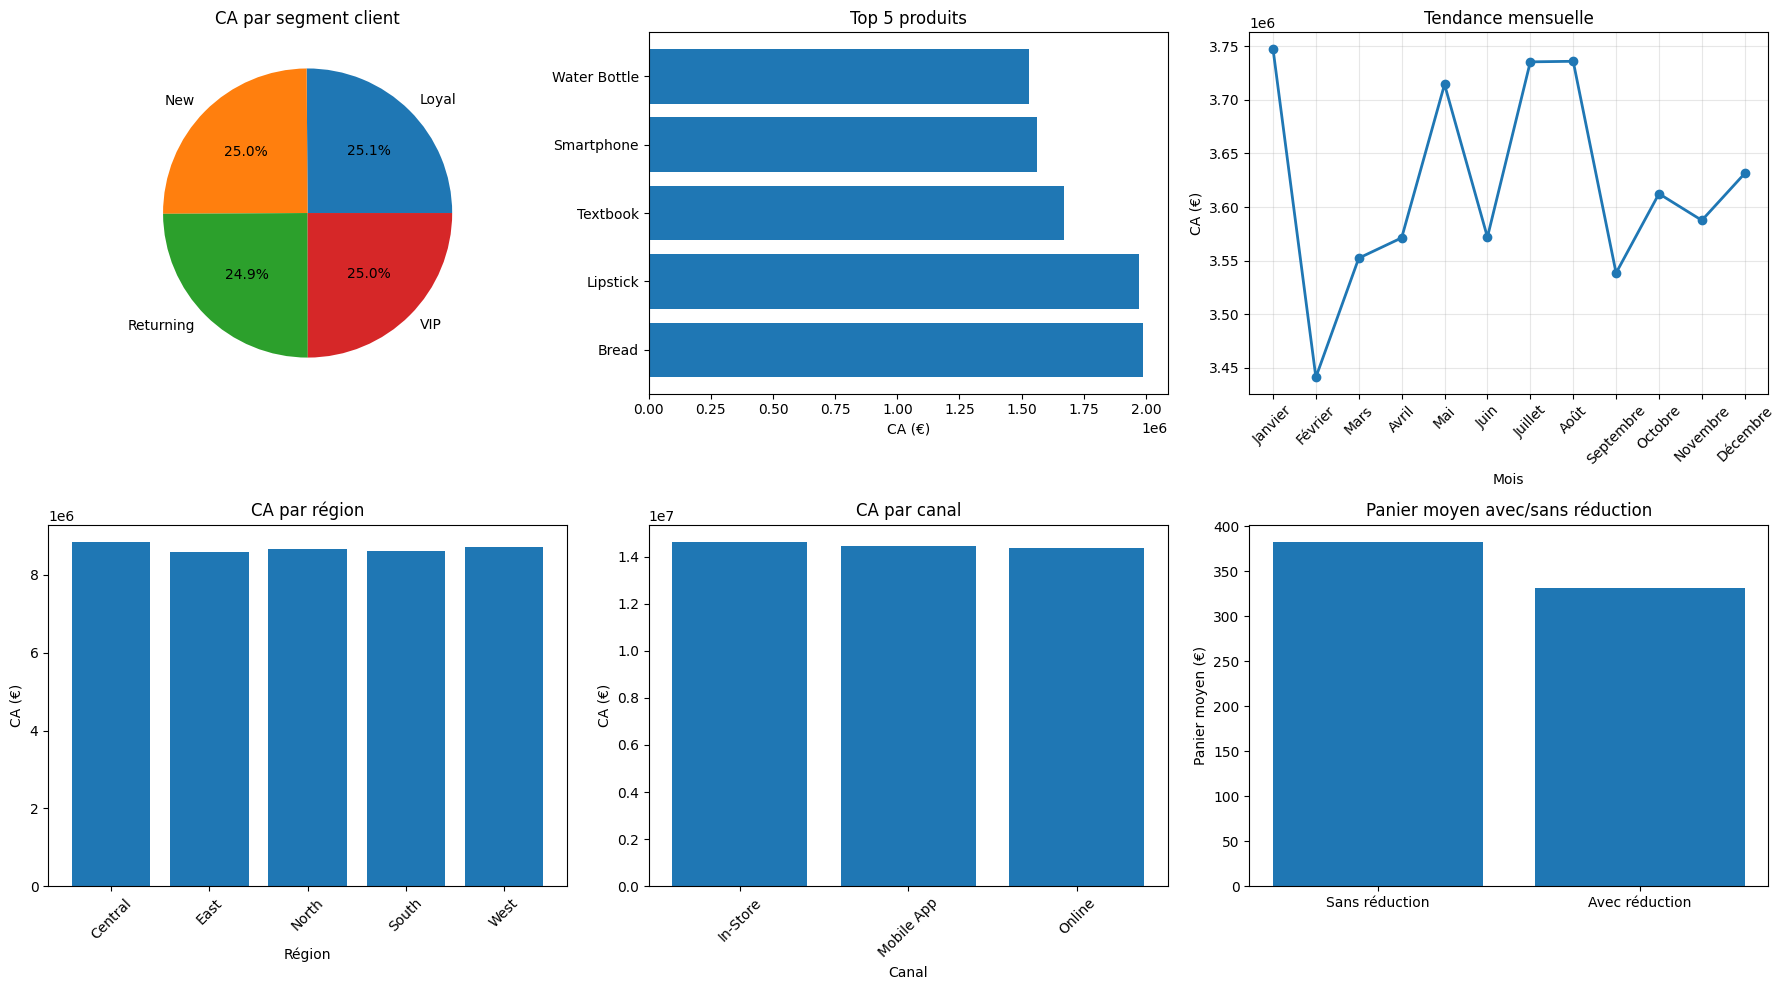

In [58]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. CA par segment
segments = df.groupby('customer_segment')['net_revenue'].sum()
axes[0, 0].pie(segments, labels=segments.index, autopct='%1.1f%%')
axes[0, 0].set_title('CA par segment client')

# 2. Top 5 produits
top_products = df.groupby('product_name')['net_revenue'].sum().sort_values(ascending=False).head(5)
axes[0, 1].barh(top_products.index, top_products.values)
axes[0, 1].set_title('Top 5 produits')
axes[0, 1].set_xlabel('CA (€)')

# 3. Ventes par mois
month_names = {1:'Janvier',2:'Février',3:'Mars',4:'Avril',5:'Mai',6:'Juin',
               7:'Juillet',8:'Août',9:'Septembre',10:'Octobre',11:'Novembre',12:'Décembre'}

monthly = df.groupby('months')['net_revenue'].sum()

months_list = [month_names[m] for m in monthly.index]

axes[0, 2].plot(months_list, monthly.values, marker='o', linewidth=2)
axes[0, 2].set_title('Tendance mensuelle')
axes[0, 2].set_xlabel('Mois')
axes[0, 2].set_ylabel('CA (€)')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].tick_params(axis='x', rotation=45)

# 4. CA par région
regions = df.groupby('region')['net_revenue'].sum()
axes[1, 0].bar(regions.index, regions.values)
axes[1, 0].set_title('CA par région')
axes[1, 0].set_xlabel('Région')
axes[1, 0].set_ylabel('CA (€)')
axes[1, 0].tick_params(axis='x', rotation=45)

# 5. CA par canal
channels = df.groupby('sales_channel')['net_revenue'].sum()
axes[1, 1].bar(channels.index, channels.values)
axes[1, 1].set_title('CA par canal')
axes[1, 1].set_xlabel('Canal')
axes[1, 1].set_ylabel('CA (€)')
axes[1, 1].tick_params(axis='x', rotation=45)

# 6. Impact des réductions
discount_impact = df.groupby('discount')['net_revenue'].mean()
axes[1, 2].bar(['Sans réduction', 'Avec réduction'], discount_impact.values)
axes[1, 2].set_title('Panier moyen avec/sans réduction')
axes[1, 2].set_ylabel('Panier moyen (€)')

plt.tight_layout()
plt.show()

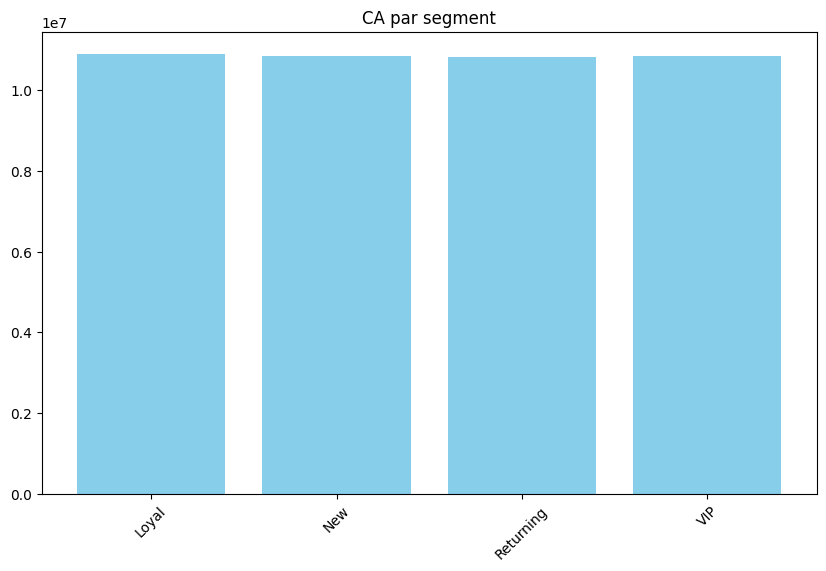

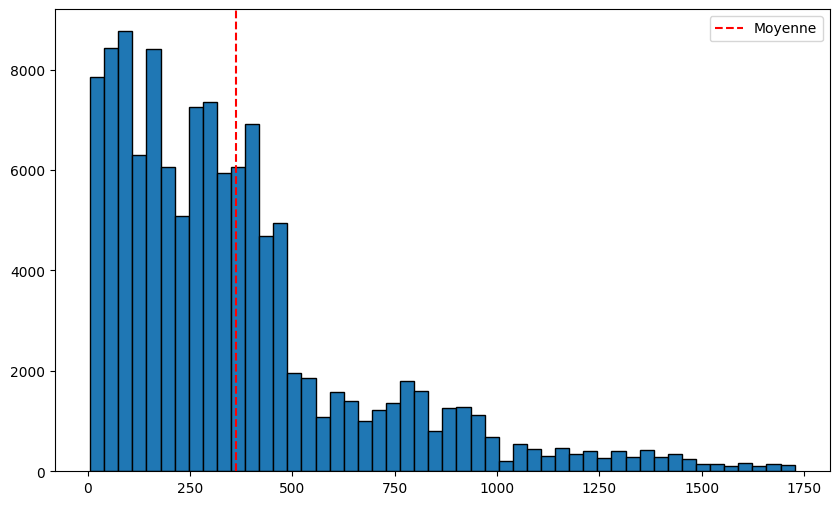

In [59]:
# Exemple avec TES données
fig, ax = plt.subplots(figsize=(10, 6))

# 1. Bar chart : CA par segment
segment_ca = df.groupby('customer_segment')['net_revenue'].sum()
ax.bar(segment_ca.index, segment_ca.values, color='skyblue')
ax.set_title('CA par segment')
plt.xticks(rotation=45)
plt.show()

# 2. Histogram : distribution des montants
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df['net_revenue'], bins=50, edgecolor='black')
ax.axvline(df['net_revenue'].mean(), color='red', linestyle='--', label='Moyenne')
ax.legend()
plt.show()

# 3. Line plot : ventes par mois
monthly = df.groupby('months')['net_revenue'].sum()
ax.plot(monthly.index, monthly.values, marker='o')
ax.set_title('Ventes mensuelles')


plt.show()


customer_age_group  18-24  25-34  35-44  45-54  55+
product_name                                       
Dumbbells             597    627    625    615  644
Jeans                 585    596    628    629  612
Shampoo               607    599    629    613  606
T-Shirt               651    598    598    585  649
Yoga Mat              562    630    618    595  659


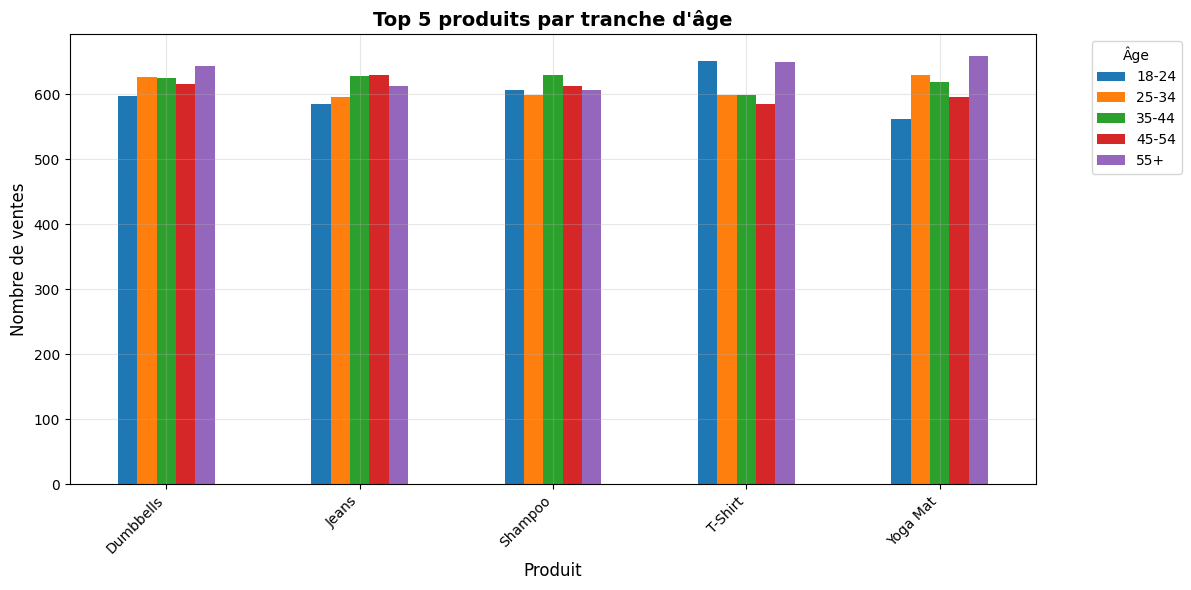

In [60]:
top_products = df['product_name'].value_counts().head(5).index.tolist()

df_top = df[df['product_name'].isin(top_products)]

sell_by_age = df_top.groupby(['product_name', 'customer_age_group']).size().unstack(fill_value=0)

print(sell_by_age)

# 4. Visualiser
fig, ax = plt.subplots(figsize=(12, 6))
sell_by_age.plot(kind='bar', ax=ax)
ax.set_title('Top 5 produits par tranche d\'âge', fontsize=14, fontweight='bold')
ax.set_xlabel('Produit', fontsize=12)
ax.set_ylabel('Nombre de ventes', fontsize=12)
ax.legend(title='Âge', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<bound method NDFrame.head of category
Beauty         6090342.91
Books          5758384.90
Electronics    5622039.83
Sports         5617327.78
Home           5405422.86
Toys           5312829.19
Groceries      5197943.10
Clothing       4435806.83
Name: net_revenue, dtype: float64>


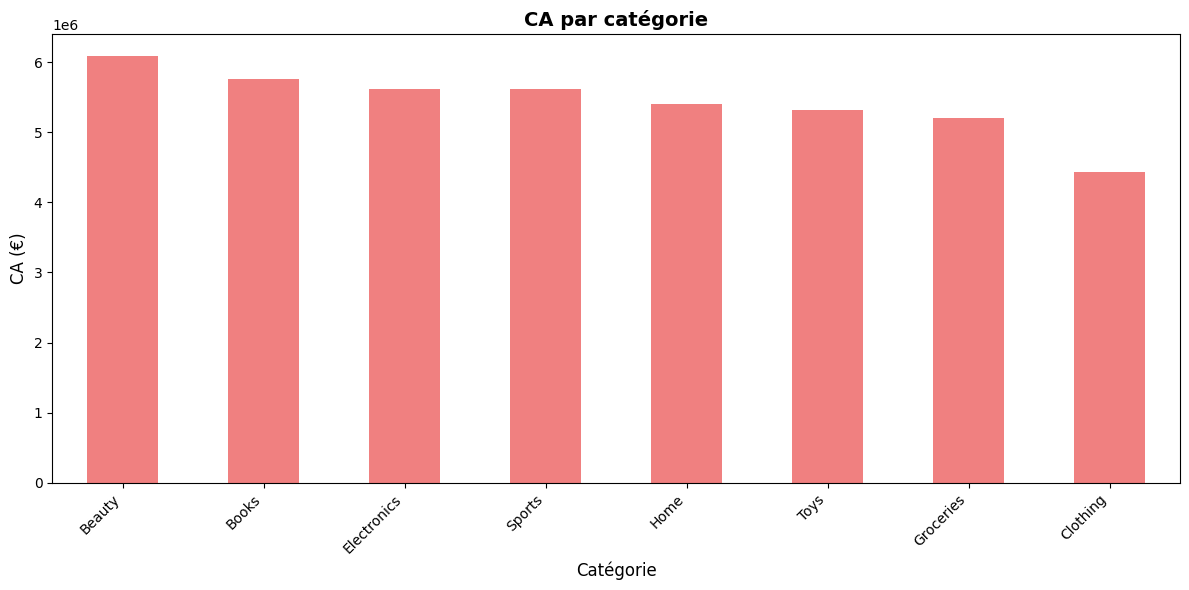

In [61]:
category_ca = df.groupby('category')['net_revenue'].sum().sort_values(ascending=False)
print(category_ca.head)

fig, ax = plt.subplots(figsize=(12, 6))
category_ca.plot(kind='bar', ax=ax, color='lightcoral')
ax.set_title('CA par catégorie', fontsize=14, fontweight='bold')
ax.set_xlabel('Catégorie', fontsize=12)
ax.set_ylabel('CA (€)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

customer_segment
VIP          17535
New          17524
Returning    17435
Loyal        17336
Name: customer_id, dtype: int64


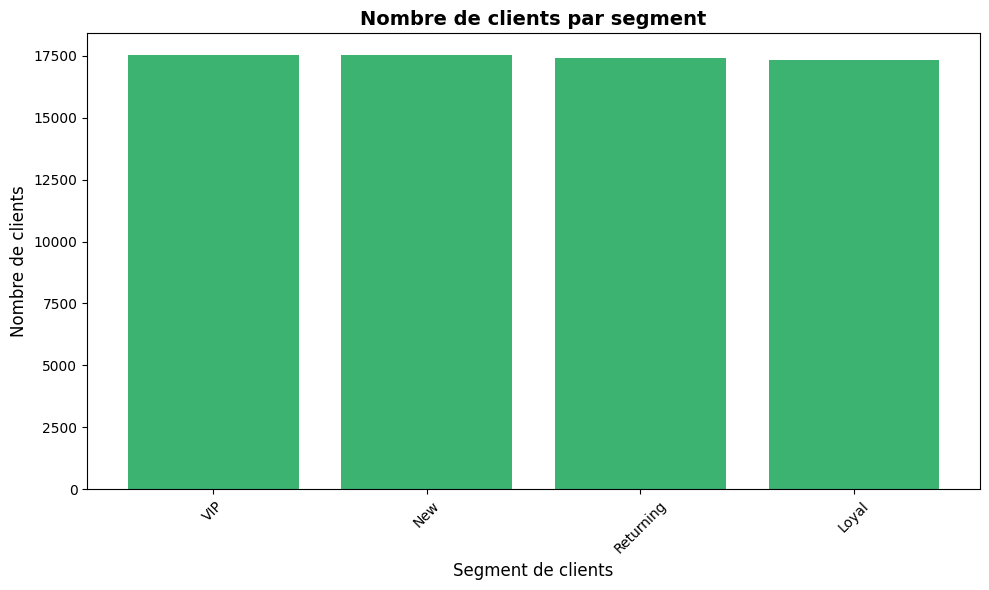

In [62]:
# Segment des clients
customer_segment = df.groupby('customer_segment')['customer_id'].nunique().sort_values(ascending=False)
print(customer_segment)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(customer_segment.index, customer_segment.values, color='mediumseagreen')
ax.set_title('Nombre de clients par segment', fontsize=14, fontweight='bold')
ax.set_xlabel('Segment de clients', fontsize=12)
ax.set_ylabel('Nombre de clients', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

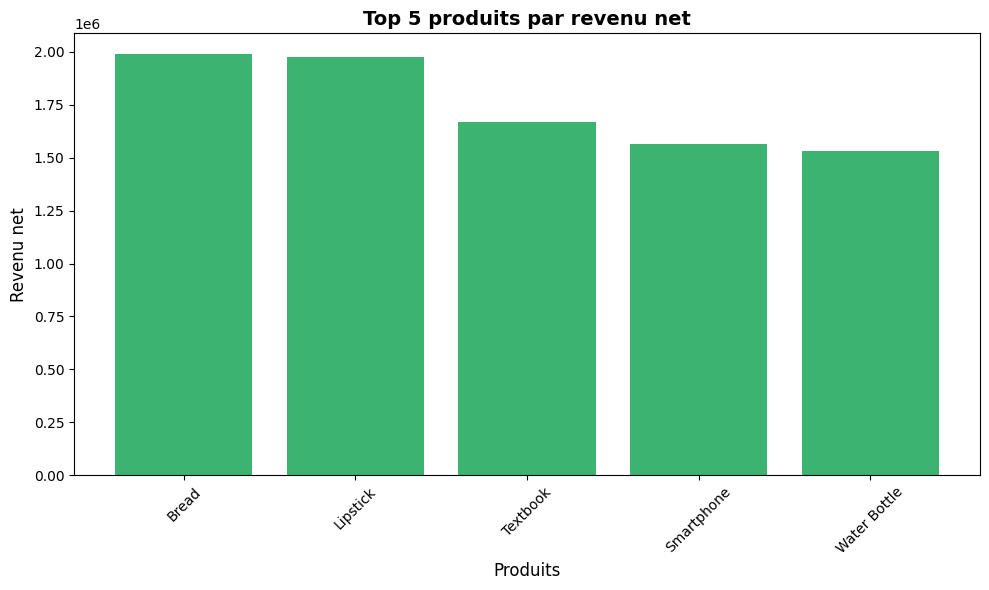

In [63]:
top_products = df.groupby('product_name')['net_revenue'].sum().sort_values(ascending=False).head(5)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(top_products.index, top_products.values, color='mediumseagreen')
ax.set_title('Top 5 produits par revenu net', fontsize=14, fontweight='bold')
ax.set_xlabel('Produits', fontsize=12)
ax.set_ylabel('Revenu net', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

                     CA_total  CA_moyen  nb_transactions  nb_clients
customer_segment                                                    
Loyal             10906615.93    363.38            30014       17336
New               10851631.53    361.48            30020       17524
Returning         10830787.52    362.83            29851       17435
VIP               10851062.42    360.32            30115       17535


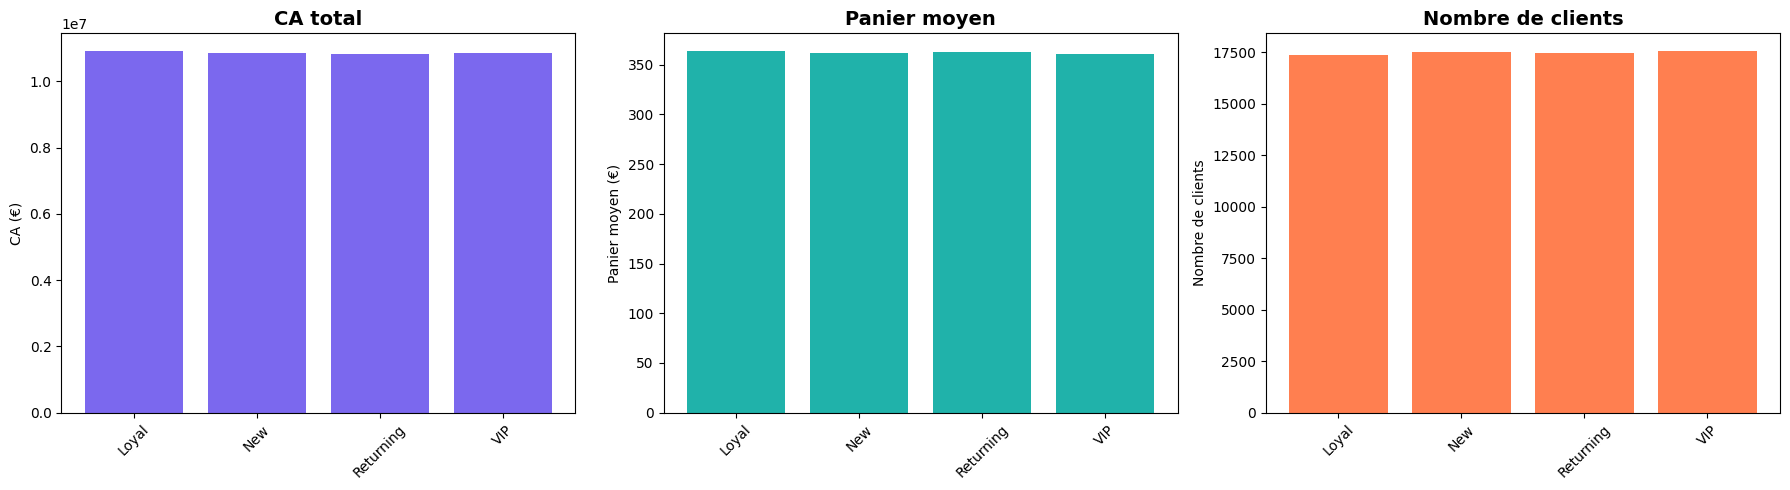

In [64]:
segment_stats = df.groupby('customer_segment').agg({
    'net_revenue': ['sum', 'mean'],
    'transaction_id': 'count',
    'customer_id': 'nunique'
}).round(2)

segment_stats.columns = ['CA_total', 'CA_moyen', 'nb_transactions', 'nb_clients']
print(segment_stats)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# CA total
axes[0].bar(segment_stats.index, segment_stats['CA_total'], color='mediumslateblue')
axes[0].set_title('CA total', fontsize=14, fontweight='bold')
axes[0].set_ylabel('CA (€)')
axes[0].tick_params(axis='x', rotation=45)

# Panier moyen
axes[1].bar(segment_stats.index, segment_stats['CA_moyen'], color='lightseagreen')
axes[1].set_title('Panier moyen', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Panier moyen (€)')
axes[1].tick_params(axis='x', rotation=45)

# Nombre de clients
axes[2].bar(segment_stats.index, segment_stats['nb_clients'], color='coral')
axes[2].set_title('Nombre de clients', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Nombre de clients')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

         CA_moyen    CA_total  nb_transactions
region                                        
Central    364.76  8843208.48            24244
East       362.66  8582320.63            23665
North      360.04  8668042.76            24075
South      358.30  8622912.33            24066
West       364.24  8723613.20            23950


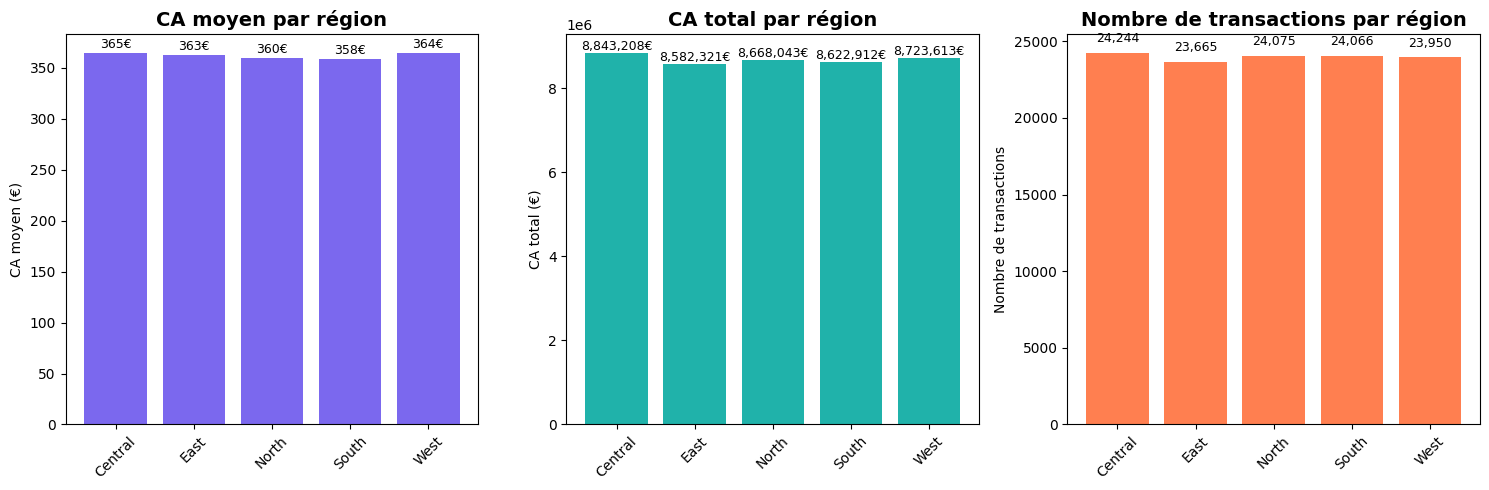

In [65]:
mean_revenue_by_region = df.groupby('region').agg({
    'net_revenue': ['mean', 'sum', 'count']
}).round(2)

mean_revenue_by_region.columns = ['CA_moyen', 'CA_total', 'nb_transactions']

print(mean_revenue_by_region)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. CA moyen
bars1 = axes[0].bar(mean_revenue_by_region.index, mean_revenue_by_region['CA_moyen'], color='mediumslateblue')
axes[0].set_title('CA moyen par région', fontsize=14, fontweight='bold')
axes[0].set_ylabel('CA moyen (€)')
# Ajouter les valeurs
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{height:.0f}€', ha='center', va='bottom', fontsize=9)
axes[0].tick_params(axis='x', rotation=45)

# 2. CA total
bars2 = axes[1].bar(mean_revenue_by_region.index, mean_revenue_by_region['CA_total'], color='lightseagreen')
axes[1].set_title('CA total par région', fontsize=14, fontweight='bold')
axes[1].set_ylabel('CA total (€)')
# Ajouter les valeurs
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 5000,
                f'{height:,.0f}€', ha='center', va='bottom', fontsize=9)
axes[1].tick_params(axis='x', rotation=45)

# 3. Nombre de transactions
bars3 = axes[2].bar(mean_revenue_by_region.index, mean_revenue_by_region['nb_transactions'], color='coral')
axes[2].set_title('Nombre de transactions par région', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Nombre de transactions')
# Ajouter les valeurs
for bar in bars3:
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height + 500,
                f'{height:,.0f}', ha='center', va='bottom', fontsize=9)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

                  Sans_réduction  Avec_réduction       diff
customer_segment                                           
Loyal                 383.637548      333.216062  50.421486
New                   383.089941      328.938981  54.150960
Returning             383.317526      332.169846  51.147680
VIP                   380.087614      330.687110  49.400505


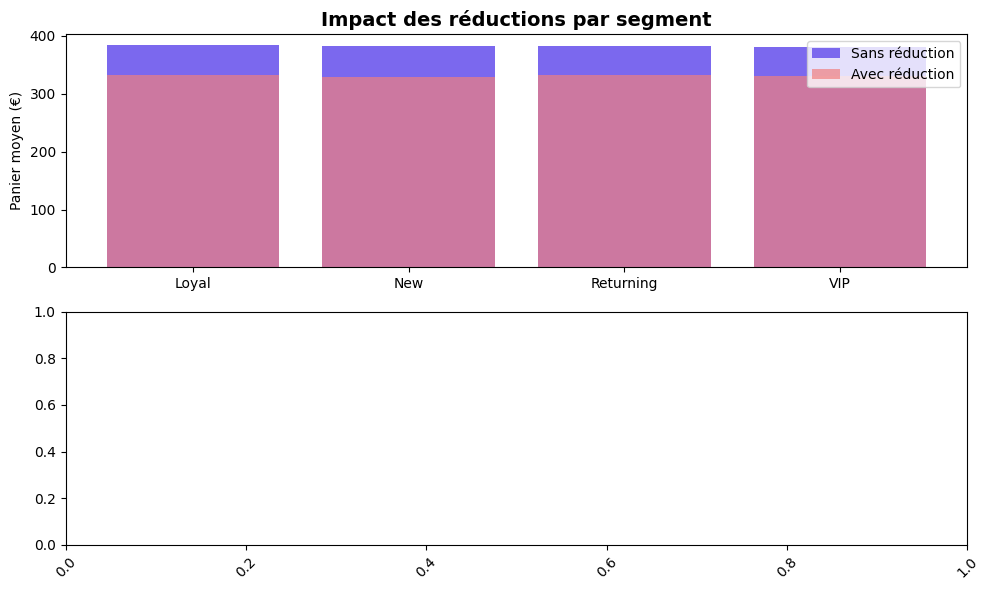

In [66]:
discount_impact_segment = df.groupby(['customer_segment', 'discount'])['net_revenue'].mean().unstack()
discount_impact_segment.columns = ['Sans_réduction', 'Avec_réduction']
discount_impact_segment['diff'] = discount_impact_segment['Sans_réduction'] - discount_impact_segment['Avec_réduction']
print(discount_impact_segment)

fig, ax = plt.subplots(2, 1, figsize=(10, 6))

ax[0].bar(discount_impact_segment.index, discount_impact_segment['Sans_réduction'], color='mediumslateblue', label='Sans réduction')
ax[0].bar(discount_impact_segment.index, discount_impact_segment['Avec_réduction'], color='lightcoral', label='Avec réduction', alpha=0.7)
ax[0].set_title('Impact des réductions par segment', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Panier moyen (€)')
ax[0].legend()
plt.xticks(rotation=45)
plt.tight_layout()


customer_segment      Loyal        New  Returning        VIP
months                                                      
1                 915277.05  907076.81  962796.76  962397.74
2                 884766.72  839993.34  831126.14  885454.14
3                 876974.92  939428.08  893671.19  842330.52
4                 933817.44  892295.94  865478.59  879727.57
5                 957521.51  924921.45  940858.81  891042.97
6                 912886.31  873543.01  904466.55  881059.15
7                 931359.43  961642.69  905642.96  936702.42
8                 900401.03  945438.15  930020.68  960009.26
9                 864390.09  862044.11  908681.29  903422.73
10                921330.77  932971.84  867390.69  890758.29
11                871634.02  866050.49  933354.39  916583.32
12                936256.64  906225.62  887299.47  901574.31


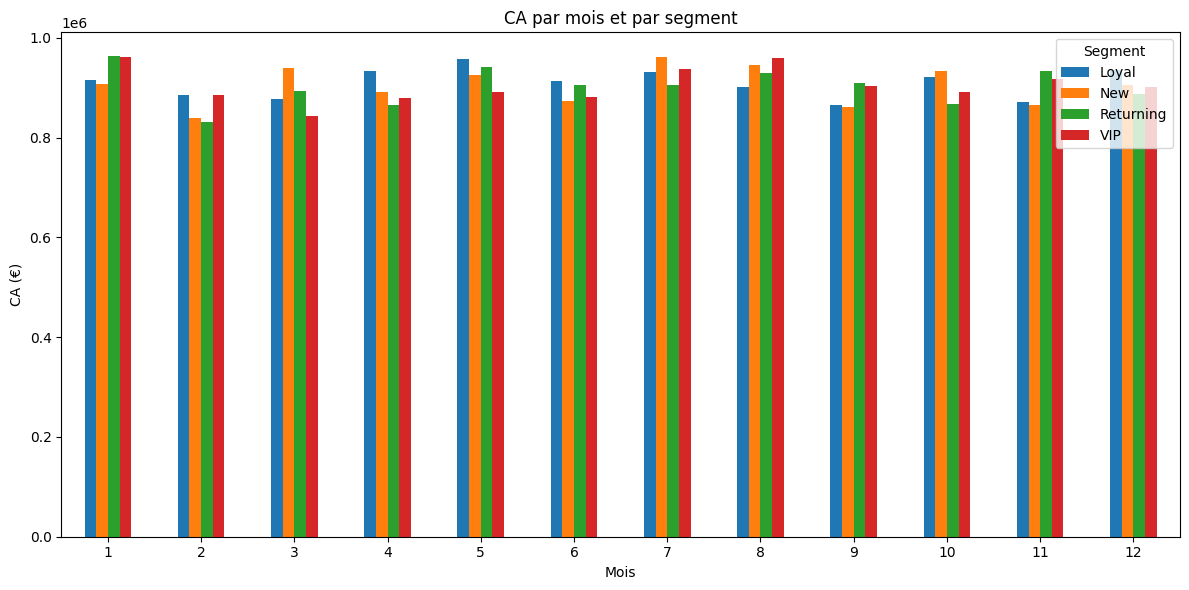

In [67]:

pivot_month_segment = df.pivot_table(
    index='months',
    columns='customer_segment',
    values='net_revenue',
    aggfunc='sum'
)
print(pivot_month_segment)

fig, ax = plt.subplots(figsize=(12, 6))
pivot_month_segment.plot(kind='bar', ax=ax)
ax.set_title('CA par mois et par segment')
ax.set_xlabel('Mois')
ax.set_ylabel('CA (€)')
ax.legend(title='Segment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

  customer_id  last_purchase_month  total_transactions  total_revenue
0     c000001                   10                   4        1337.67
1     c000002                   11                   6        1330.54
2     c000003                   11                   4        1219.71
3     c000004                    9                   4        2597.00
4     c000005                    9                   3         720.48


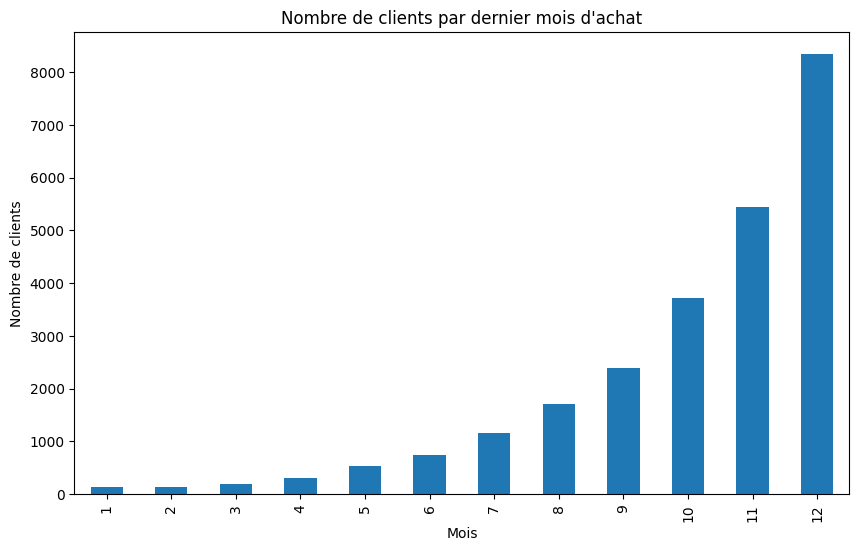

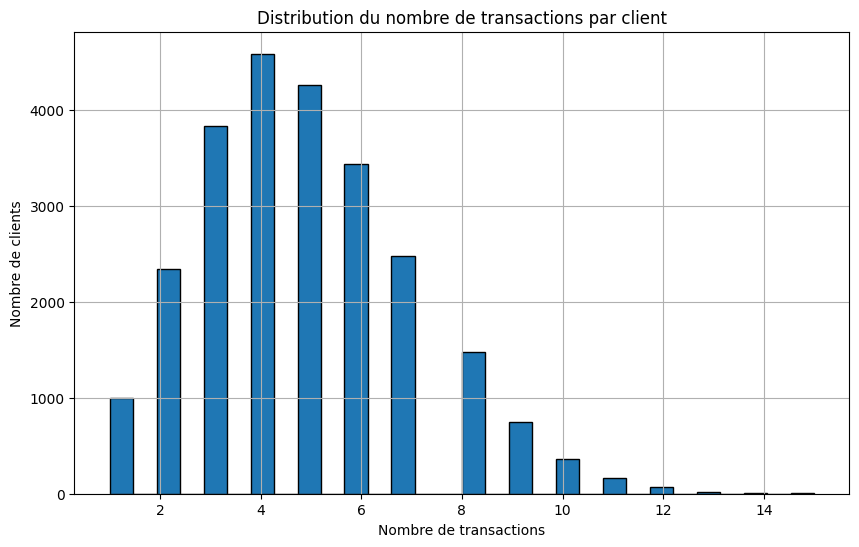

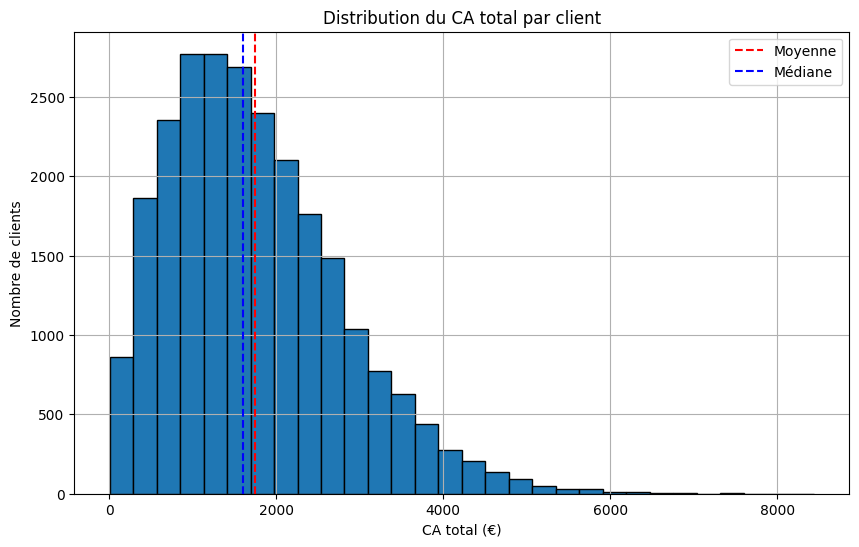

In [68]:
client_recency = df.groupby('customer_id')['months'].max().reset_index()
client_recency.columns = ['customer_id', 'last_purchase_month']

client_frequency = df.groupby('customer_id')['transaction_id'].count().reset_index()
client_frequency.columns = ['customer_id', 'total_transactions']

client_monetary = df.groupby('customer_id')['net_revenue'].sum().reset_index()
client_monetary.columns = ['customer_id', 'total_revenue']

rfm = client_recency.merge(client_frequency, on='customer_id')
rfm = rfm.merge(client_monetary, on='customer_id')

print(rfm.head())

fig, ax = plt.subplots(figsize=(10, 6))
client_recency['last_purchase_month'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_title('Nombre de clients par dernier mois d\'achat')
ax.set_xlabel('Mois')
ax.set_ylabel('Nombre de clients')
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
client_frequency['total_transactions'].hist(bins=30, edgecolor='black')
ax.set_title('Distribution du nombre de transactions par client')
ax.set_xlabel('Nombre de transactions')
ax.set_ylabel('Nombre de clients')
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
client_monetary['total_revenue'].hist(bins=30, edgecolor='black')
ax.axvline(client_monetary['total_revenue'].mean(), color='red', linestyle='--', label='Moyenne')
ax.axvline(client_monetary['total_revenue'].median(), color='blue', linestyle='--', label='Médiane')
ax.legend()
ax.set_title('Distribution du CA total par client')
ax.set_xlabel('CA total (€)')
ax.set_ylabel('Nombre de clients')
plt.show()


day_of_week
Wednesday    6289736.48
Saturday     6239999.31
Thursday     6234352.28
Monday       6206837.88
Tuesday      6169741.08
Sunday       6152483.87
Friday       6146946.50
Name: net_revenue, dtype: float64


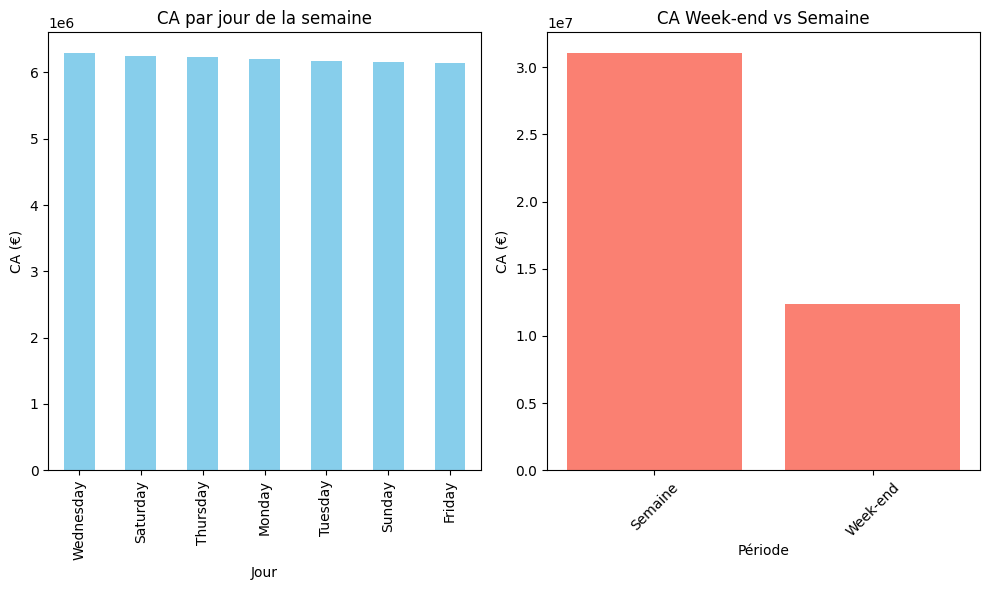

In [ ]:
day_revenue = df.groupby('day_of_week')['net_revenue'].sum().sort_values(ascending=False)
print(day_revenue)

compare_week_end = df.groupby("is_weekend")['net_revenue'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(1,2, figsize=(10, 6))
day_revenue.plot(kind='bar', ax=ax[0], color='skyblue')
ax[0].set_title('CA par jour de la semaine')
ax[0].set_xlabel('Jour')
ax[0].set_ylabel('CA (€)')
plt.xticks(rotation=45)
plt.tight_layout()

ax[1].bar(compare_week_end.index.map({False: 'Semaine', True: 'Week-end'}), compare_week_end.values, color='salmon')
ax[1].set_title('CA Week-end vs Semaine')
ax[1].set_xlabel('Période')
ax[1].set_ylabel('CA (€)')
plt.tight_layout()
plt.show()